<a href="https://colab.research.google.com/github/evucelic/Diplomski-Projekt/blob/hmm-vae/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
data = pd.read_csv(
    "/content/100_Portfolios_10x10_Daily_valueweighted.csv",
    parse_dates=True,
    low_memory=False
)
data = data.set_index("Date")
data.head()

,SMALL LoBM,ME1 BM2,ME1 BM3,ME1 BM4,ME1 BM5,ME1 BM6,ME1 BM7,ME1 BM8,ME1 BM9,SMALL HiBM,...,BIG LoBM,ME10 BM2,ME10 BM3,ME10 BM4,ME10 BM5,ME10 BM6,ME10 BM7,ME10 BM8,ME10 BM9,BIG HiBM
Date,,,,,,,,,,,,,,,,,,,,,
19260701,-99.99,0.00,-99.99,1.59,-3.08,4.64,2.57,3.81,-0.52,-0.84,...,0.00,1.10,-0.15,-0.03,0.52,0.48,-0.43,-0.08,0.17,-99.99
19260702,-99.99,-0.27,-99.99,0.00,-0.97,-4.10,0.31,-0.47,2.74,-0.27,...,0.31,0.71,0.97,0.57,0.52,0.15,0.63,-0.04,0.34,-99.99
19260706,-99.99,1.01,-99.99,-4.69,2.35,-1.79,0.00,2.44,-5.18,-0.23,...,0.49,-0.19,0.89,0.31,-0.12,-0.18,-0.33,-0.40,-0.34,-99.99
19260707,-99.99,-1.67,-99.99,4.92,0.51,5.27,0.00,-0.74,-0.24,-0.02,...,-0.20,-0.01,0.66,0.38,0.03,0.25,-0.29,0.52,0.17,-99.99
19260708,-99.99,0.00,-99.99,1.56,-0.51,-1.06,0.00,4.90,0.45,0.26,...,0.56,-0.12,0.35,0.55,-0.14,0.19,-0.12,0.54,0.51,-99.99


In [20]:
data= data.replace(-99.99, np.nan)
data = data.replace(-999, np.nan)

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26110 entries, 19260701 to 20251031
Data columns (total 100 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   SMALL LoBM  23562 non-null  float64
 1   ME1 BM2     23230 non-null  float64
 2   ME1 BM3     23208 non-null  float64
 3   ME1 BM4     24616 non-null  float64
 4   ME1 BM5     25171 non-null  float64
 5   ME1 BM6     25805 non-null  float64
 6   ME1 BM7     25813 non-null  float64
 7   ME1 BM8     26107 non-null  float64
 8   ME1 BM9     26110 non-null  float64
 9   SMALL HiBM  26110 non-null  float64
 10  ME2 BM1     23530 non-null  float64
 11  ME2 BM2     24323 non-null  float64
 12  ME2 BM3     25421 non-null  float64
 13  ME2 BM4     26102 non-null  float64
 14  ME2 BM5     25807 non-null  float64
 15  ME2 BM6     26110 non-null  float64
 16  ME2 BM7     26110 non-null  float64
 17  ME2 BM8     26110 non-null  float64
 18  ME2 BM9     26110 non-null  float64
 19  ME2 BM10    26110 n

In [22]:
data = data.fillna(0)
data = data / 100.0
data = data.astype(np.float32)
data.index = pd.to_datetime(data.index, format="%Y%m%d")

In [23]:
# print(data.min().min(), data.max().max())
# print(data.describe(percentiles=[0.001, 0.01, 0.99, 0.999]).T.sort_values("min").head(5))
# print(data.info())

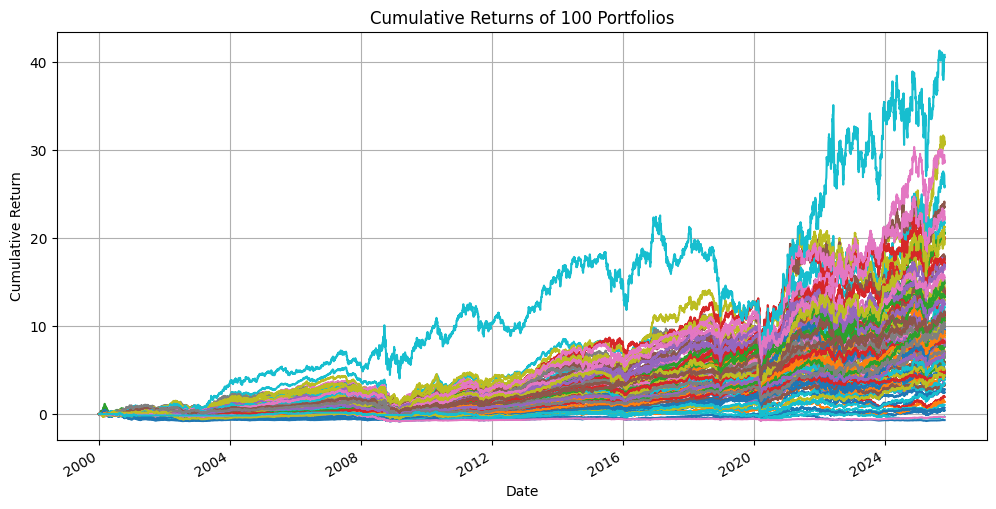

In [24]:
cum_returns = (1 + data.loc[data.index > "2000-01-01"]).cumprod() - 1
cum_returns.plot(figsize=(12, 6))
plt.title("Cumulative Returns of 100 Portfolios")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid()
plt.legend().set_visible(False)
plt.show()

Podaci od 02.07.1945 - 31.10.2025. Podaci koji nedostaju su zamijenjeni s 0 (stacionarni trenutci)

Portfelji su formirani na temelju 2 karakteristike, size(market equity) i value (Book-to-market)

Napomena za size:
"A fundamental problem in handling accounting data is the look-ahead bias; we must not include data in forming a portfolio that was not available knowledge at the time. Of course, researchers have more information when looking into the past than agents actually had at that moment. However, abnormal excess returns from a trading strategy should not rely on an information advantage because the differential cannot be the result of informed agents’ trades. Hence, we have to lag accounting information.

We continue to lag market capitalization and firm size by one month" source: https://www.tidy-finance.org/r/value-and-bivariate-sorts.html



Kako su točno formirani portfelji?
U danom trenutku t, uzimamo cijeli universe dionica u tom trenutku i pridružimo im dvije karakteristike npr. size i value.
Recimo da svakoj dionici pridružimo size od 1-10 i value od 1-10. Vrijednosti 1-10 predstavljaju decile veličine/value s NYSE burze, računaju se jednom godišnje te su stacionarni godinu dana.

Grupiramo dionice na temelju labela i formiramo 10x10 = 100 portfelja u svakom trenutku, weightanih proporcionalno market capu (lagganom 1mj).

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

![image](https://github.com/evucelic/Diplomski-Projekt/blob/hmm-vae/images/1-s2.0-S0020025525003160-gr001.jpg?raw=1)

In [26]:
# TODO MLP za duzi forcasting unaprijed
# class MLP(nn.Module):
#     """
#     Learn VAR(1) dynamics: p(z_t | z_{t-1}).
#     """
#     def __init__(self, z_dim, hidden_dim):
#         super().__init__()
#         self.fc1 = nn.Linear(z_dim, hidden_dim)
#         self.fc_mu = nn.Linear(hidden_dim, z_dim)
#         self.fc_logvar = nn.Linear(hidden_dim, z_dim)

#     def forward(self, z_prev):
#         h = F.relu(self.fc1(z_prev))
#         mu = self.fc_mu(h)
#         logvar = self.fc_logvar(h)
#         return mu, logvar

In [27]:
# https://stats.stackexchange.com/questions/60680/kl-divergence-between-two-multivariate-gaussians
# TODO https://www.microsoft.com/en-us/research/blog/less-pain-more-gain-a-simple-method-for-vae-training-with-less-of-that-kl-vanishing-agony/

In [28]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

class FinancialDataset(Dataset):
    def __init__(self, returns_matrix, t_past=60, t_future=20):
        if isinstance(returns_matrix, np.ndarray):
            self.data = torch.from_numpy(returns_matrix).float()
        else:
            self.data = torch.tensor(returns_matrix, dtype=torch.float32)

        self.t_past = t_past
        self.t_future = t_future

    def __len__(self):
        return len(self.data) - (self.t_past + self.t_future) + 1

    def __getitem__(self, idx):
        start_idx = idx
        split_idx = idx + self.t_past
        end_idx = split_idx + self.t_future

        x_past = self.data[start_idx : split_idx]      # (60, 100)
        x_future = self.data[split_idx : end_idx]      # (20, 100)

        return x_past, x_future


In [29]:
class CVAE(nn.Module):
    def __init__(self, n_assets=100, t_past=60, t_future=20, z_dim=10):
        super().__init__()
        self.t_past = t_past
        self.t_future = t_future
        self.n_assets = n_assets
        self.z_dim = z_dim

        # ENCODER
        # Input: Flattened Future (20*100) + Flattened Past (60*100)
        input_dim = (t_future + t_past) * n_assets
        self.enc_fc1 = nn.Linear(input_dim, 512)
        self.enc_mu = nn.Linear(512, z_dim)
        self.enc_logvar = nn.Linear(512, z_dim)

        # CONDITION ENCODER
        # Compresses the 60-day history into a "summary" vector
        cond_input_dim = t_past * n_assets
        self.cond_fc = nn.Linear(cond_input_dim, 32)

        # DECODER
        # Input: Latent Z (16) + Condition (32)
        dec_input_dim = z_dim + 32
        self.dec_fc1 = nn.Linear(dec_input_dim, 512)
        self.dec_out = nn.Linear(512, t_future * n_assets) # Output flattened future

    def encode(self, x_past, x_future):
        flat_past = x_past.flatten(start_dim=1)     # (Batch, 60*100)
        flat_future = x_future.flatten(start_dim=1) # (Batch, 20*100)

        # Encoder sees EVERYTHING to learn the posterior
        x_full = torch.cat([flat_past, flat_future], dim=1)
        h = F.relu(self.enc_fc1(x_full))
        return self.enc_mu(h), self.enc_logvar(h)

    def decode(self, z, x_past):
        flat_past = x_past.flatten(start_dim=1)
        cond_summary = F.relu(self.cond_fc(flat_past))

        decoder_input = torch.cat([z, cond_summary], dim=1)

        h = F.relu(self.dec_fc1(decoder_input))
        flat_out = self.dec_out(h)

        return flat_out.view(-1, self.t_future, self.n_assets)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x_past, x_future):
        mu, logvar = self.encode(x_past, x_future)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z, x_past)
        return x_recon, mu, logvar, z


In [30]:
from torch.distributions import Normal, StudentT

def kld_gaussian_to_student(z, mu, logvar, df=3.0):
    """
    Computes KL( Gaussian(mu, sigma) || StudentT(df) ) numerically.
    """
    # Q(z|x): Gaussian predicted by the encoder
    scale = torch.exp(0.5 * logvar)
    q_dist = Normal(loc=mu, scale=scale)

    # P(z): Student-t Prior (Fixed, centered at 0)
    p_dist = StudentT(df=df, loc=torch.zeros_like(mu), scale=1.0)

    log_q = q_dist.log_prob(z).sum(dim=1)
    log_p = p_dist.log_prob(z).sum(dim=1)

    # KL = E[log Q - log P]
    kld = torch.mean(log_q - log_p)

    return kld


In [31]:
def loss_function(recon_x, x, z, mu, logvar, df=4.0, beta=0.001):
    """
    Computes VAE loss using Monte Carlo KL estimation.

    Args:
        recon_x: Reconstructed input (Decoder output)
        x: Original input
        z: Latent sample used to generate recon_x (sampled from Q)
        mu: Encoder mean
        logvar: Encoder log variance
        df: Degrees of freedom for the Student-t prior
    """
    # Reconstruction Loss (MSE), TODO change to sth else maybe
    MSE = F.mse_loss(recon_x, x, reduction='sum')

    # KLD between gaussian and student for given df
    kld_mean = kld_gaussian_to_student(z, mu, logvar, df=df)
    batch_size = x.size(0)
    KLD_SUM = kld_mean * batch_size

    # anneal KLD by factor of beta
    return MSE + KLD_SUM * beta


In [32]:
# --- HYPERPARAMETERS ---
EPOCHS = 65
BATCH_SIZE = 64
T_PAST = 60
T_FUTURE = 20
GAP = T_FUTURE
DF = 4.0

# Cyclical Beta Schedule
TARGET_BETA = 0.001
CYCLES = 5
R_PROP = 0.7  # 70% ramp up, 30% plateau

# --- DATA PREP ---
split_idx = int(len(data) * 0.8)
train_data = data.iloc[:split_idx].values
test_data = data.iloc[split_idx + GAP:].values

train_dataset = FinancialDataset(train_data, t_past=T_PAST, t_future=T_FUTURE)
test_dataset = FinancialDataset(test_data, t_past=T_PAST, t_future=T_FUTURE)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE, shuffle=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE, shuffle=False
)

# --- MODEL SETUP ---
model = CVAE(n_assets=100, t_past=T_PAST, t_future=T_FUTURE).cuda()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

steps_per_epoch = len(train_loader)
total_steps = EPOCHS * steps_per_epoch
cycle_steps = total_steps // CYCLES

def get_current_beta(global_step, cycle_steps, r_prop, target_beta):
    """Calculates cyclical beta value based on global step."""
    cycle_progress = (global_step % cycle_steps) / cycle_steps
    if cycle_progress < r_prop:
        return target_beta * (cycle_progress / r_prop)
    return target_beta

print(f"Starting training on {len(train_loader.dataset)} samples.")
print(f"Annealing: {CYCLES} cycles of {cycle_steps} steps each.")

# --- TRAINING LOOP ---
global_step = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for past, future in train_loader:
        past, future = past.cuda(), future.cuda()

        current_beta = get_current_beta(global_step, cycle_steps, R_PROP, TARGET_BETA)
        global_step += 1

        recon_future, mu, logvar, z = model(past, future)
        loss = loss_function(recon_future, future, z, mu, logvar, df=DF, beta=current_beta)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader.dataset)

    # --- EVALUATION LOOP ---
    model.eval()
    test_metrics = {'loss': 0, 'mse': 0, 'kld': 0}

    with torch.no_grad():
        for past, future in test_loader:
            past, future = past.cuda(), future.cuda()
            recon_future, mu, logvar, z = model(past, future)

            mse_val = F.mse_loss(recon_future, future, reduction='sum')
            kld_mean = kld_gaussian_to_student(z, mu, logvar, df=DF)
            kld_sum = kld_mean * past.size(0)

            test_metrics['mse'] += mse_val.item()
            test_metrics['kld'] += kld_sum.item()
            test_metrics['loss'] += (mse_val + (kld_sum * current_beta)).item()

    # Normalize metrics
    n_test = len(test_loader.dataset)
    avg_test = {k: v / n_test for k, v in test_metrics.items()}

    print(f'Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.5f} | Test Loss: {avg_test["loss"]:.5f}')
    print(f'   Test Breakdown -> MSE: {avg_test["mse"]:.6f} | KLD: {avg_test["kld"]:.4f}')


Starting training on 20809 samples.
Annealing: 5 cycles of 4238 steps each.
Epoch 1/65 | Train Loss: 1.05458 | Test Loss: 0.38182
   Test Breakdown -> MSE: 0.377196 | KLD: 42.2472
Epoch 2/65 | Train Loss: 0.50809 | Test Loss: 0.37889
   Test Breakdown -> MSE: 0.369709 | KLD: 41.8268
Epoch 3/65 | Train Loss: 0.50041 | Test Loss: 0.37710
   Test Breakdown -> MSE: 0.364590 | KLD: 37.9939
Epoch 4/65 | Train Loss: 0.49554 | Test Loss: 0.38391
   Test Breakdown -> MSE: 0.368947 | KLD: 34.0568
Epoch 5/65 | Train Loss: 0.49155 | Test Loss: 0.38523
   Test Breakdown -> MSE: 0.368431 | KLD: 30.5863
Epoch 6/65 | Train Loss: 0.48727 | Test Loss: 0.39039
   Test Breakdown -> MSE: 0.372135 | KLD: 27.6991
Epoch 7/65 | Train Loss: 0.48253 | Test Loss: 0.38866
   Test Breakdown -> MSE: 0.369443 | KLD: 24.9902
Epoch 8/65 | Train Loss: 0.47877 | Test Loss: 0.39260
   Test Breakdown -> MSE: 0.371825 | KLD: 23.6401
Epoch 9/65 | Train Loss: 0.47485 | Test Loss: 0.39616
   Test Breakdown -> MSE: 0.373850 | K

In [33]:
def get_latents(model, dataloader):
    model.eval()
    all_mus = []

    with torch.no_grad():
        for past, future in dataloader:
            past, future = past.cuda(), future.cuda()
            mu, logvar = model.encode(past, future)
            all_mus.append(mu.cpu())
    return torch.cat(all_mus, dim=0)


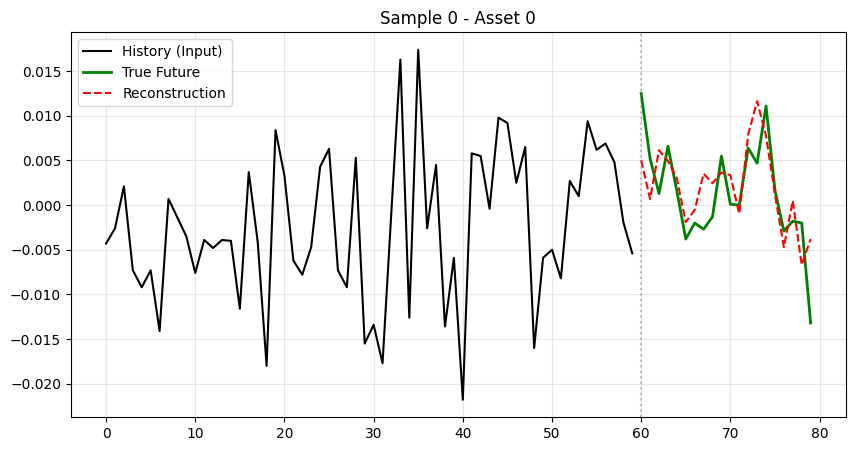

In [34]:
import matplotlib.pyplot as plt

def plot_prediction(model, dataset, sample_idx=0, asset_idx=0):
    model.eval()

    past_tensor, future_tensor = dataset[sample_idx]

    past = past_tensor.unsqueeze(0).cuda()    # Shape: (1, 60, 100)
    future = future_tensor.unsqueeze(0).cuda() # Shape: (1, 20, 100)

    with torch.no_grad():
        recon_future, mu, logvar, z = model(past, future)

    history = past_tensor[:, asset_idx].numpy()
    true_future = future_tensor[:, asset_idx].numpy()
    pred_future = recon_future.cpu().squeeze(0)[:, asset_idx].numpy()

    t_history = range(0, 60)
    t_future = range(60, 80)

    plt.figure(figsize=(10, 5))

    plt.plot(t_history, history, label='History (Input)', color='black')

    plt.plot(t_future, true_future, label='True Future', color='green', linewidth=2)

    plt.plot(t_future, pred_future, label='Reconstruction', color='red', linestyle='--')

    plt.title(f"Sample {sample_idx} - Asset {asset_idx}")
    plt.axvline(x=60, color='gray', linestyle=':', alpha=0.5) # Divider line
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_prediction(model, test_dataset, sample_idx=0, asset_idx=0)


In [35]:
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 12.2 MB/s eta 0:00:00


In [39]:
from hmmlearn.hmm import GaussianHMM
from sklearn.utils import check_random_state
from collections import defaultdict


In [45]:
import warnings

def get_n_params(model):
    """
    Calculate the number of free parameters in a GaussianHMM.
    k = (N*N - N) + (N-1) + N*M + N*(M*(M+1)/2)
    where N=n_components, M=n_features (z_dim)
    """
    n_features = model.n_features
    n_components = model.n_components

    # Transition matrix probabilities (rows sum to 1, so N*(N-1))
    n_trans = n_components * (n_components - 1)

    # Start probabilities (sum to 1, so N-1)
    n_start = n_components - 1

    # Means (N * M)
    n_means = n_components * n_features

    # Covariances
    if model.covariance_type == 'full':
        # N * (M * (M + 1) / 2) because covariance matrices are symmetric
        n_covars = n_components * (n_features * (n_features + 1) // 2)
    elif model.covariance_type == 'diag':
        # N * M (diagonal elements only)
        n_covars = n_components * n_features
    elif model.covariance_type == 'spherical':
        # N (one variance per state)
        n_covars = n_components
    else: # tied
        n_covars = n_features * (n_features + 1) // 2

    return n_trans + n_start + n_means + n_covars

def evaluate_hmm(latents, rs, ns, loop):
    aic = []
    bic = []
    lls = []
    convergence_status = []
    iterations = []
    models = defaultdict(list)
    best_models = {}

    X = latents
    lengths = [len(X)]
    N = len(X)

    for n in ns:
        best_ll = -np.inf
        best_model = None

        for i in range(loop):
            with warnings.catch_warnings():
                warnings.filterwarnings('ignore', category=DeprecationWarning)
                current_rs = check_random_state(rs + i)

                h = GaussianHMM(
                    n_components=n,
                    n_iter=2000,
                    tol=1e-6,
                    random_state=current_rs,
                    covariance_type="full",
                    verbose=False,
                )

                try:
                    h.fit(X, lengths)
                    score = h.score(X, lengths)

                    models[n].append((h, score))

                    if score > best_ll:
                        best_ll = score
                        best_model = h
                except ValueError as e:
                    print(f"Failed to fit model with {n} states (iter {i}): {e}")
                    continue

        if best_model is None:
            print(f"Could not fit any model for {n} states.")
            continue

        best_models[n] = best_model

        n_params = get_n_params(best_model)

        # BIC = -2*LL + k*ln(N)
        current_bic = -2 * best_ll + n_params * np.log(N)

        # AIC = -2*LL + 2*k
        current_aic = -2 * best_ll + 2 * n_params

        aic.append(current_aic)
        bic.append(current_bic)
        lls.append(best_ll)
        convergence_status.append(best_model.monitor_.converged)
        iterations.append(best_model.monitor_.iter)

    print("Convergence Status: ", convergence_status)
    print("Iterations: ", iterations)

    return aic, bic, lls, convergence_status, iterations, best_models, models


In [46]:
train_loader_ordered = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

train_latents = get_latents(model, train_loader_ordered)
test_latents = get_latents(model, test_loader)

aic, bic, lls, conv, iters, best_models, all_models = evaluate_hmm(
    latents=train_latents,
    rs=42,
    ns=[4],
    loop=15
)

best_hmm = best_models[4]


Convergence Status:  [True]
Iterations:  [64]


In [47]:
import seaborn as sns
import matplotlib.patches as mpatches

def plot_most_probable_regime(
    state_probs,
    n_regimes,
    time_index=None,
    fred_recessions=None,
    title="Dominant Market Regime",
    ax=None,
):
    """
    Plots the most probable regime at each time step using background shading.

    Parameters:
        state_probs (np.ndarray): Array of state probabilities (T, N).
        n_regimes (int): Number of regimes.
        time_index (pd.DatetimeIndex, optional): Time index. Defaults to integer index.
        fred_recessions (pd.DataFrame, optional): Recession dates.
    """
    colors = ['#0072B2', '#D55E00', '#009E73', '#CC79A7']

    if time_index is None:
        x_values = np.arange(len(state_probs))
        use_dates = False
    else:
        x_values = time_index
        use_dates = True

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 3))
    predicted_states = np.argmax(state_probs, axis=1)
    ax.step(x_values, predicted_states, where='post', color='black', linewidth=0.5, alpha=0.3)
    y_min, y_max = -0.5, n_regimes - 0.5

    for i in range(n_regimes):
        mask = (predicted_states == i)

        ax.fill_between(
            x_values,
            y_min,
            y_max,
            where=mask,
            color=colors[i % len(colors)],
            alpha=0.4,
            step='post',
            label=f"Regime {i+1}"
        )

    if fred_recessions is not None and use_dates:
        for _, row in fred_recessions.iterrows():
            if row["Peak"] < x_values[-1] and row["Trough"] > x_values[0]:
                ax.axvspan(
                    row["Peak"],
                    row["Trough"],
                    facecolor="none",
                    edgecolor="black",
                    hatch="///",
                    alpha=0.3,
                    zorder=10
                )

    ax.set_ylim(y_min, y_max)
    ax.set_xlim(x_values[0], x_values[-1])

    ax.set_yticks(range(n_regimes))
    ax.set_yticklabels([f"Regime {i+1}" for i in range(n_regimes)])

    ax.set_title(title, fontsize=11)

    patches = [mpatches.Patch(color=colors[i % len(colors)], alpha=0.4, label=f'Regime {i+1}') for i in range(n_regimes)]
    if fred_recessions is not None and use_dates:
        patches.append(mpatches.Patch(facecolor="none", edgecolor="black", hatch="///", label='US Recession'))

    ax.legend(handles=patches, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=n_regimes+1, frameon=False)

    sns.despine(ax=ax, left=True)
    ax.grid(axis='x', alpha=0.3)

    return ax


<Axes: title={'center': 'Dominant Market Regime'}>

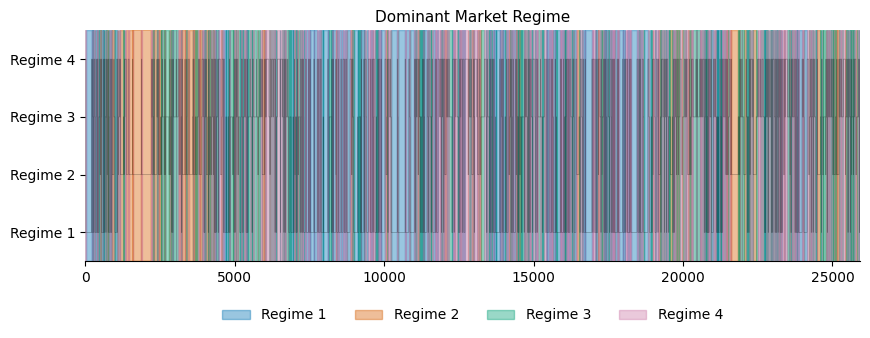

In [48]:
whole_latents = np.concatenate([train_latents, test_latents], axis=0)
state_probs_4 = best_hmm.predict_proba(whole_latents, lengths = len(whole_latents))
plot_most_probable_regime(state_probs_4, 4)


In [49]:
# TODO napravi cross validaciju
# from sklearn.model_selection import TimeSeriesSplit

# max_years_lookback = 30

# tscv_y = TimeSeriesSplit(n_splits=30, max_train_size=max_years_lookback*252, test_size=252)
# tscv_q = TimeSeriesSplit(n_splits=20, max_train_size=max_years_lookback*252, test_size=63+50)
# tscv_m = TimeSeriesSplit(n_splits=10, max_train_size=max_years_lookback*252, test_size=21)
